In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Targets: P_solar_total, Vbat, Tbatt
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print("\nKNN Algorithm Summary:")
print("  - Predicts by averaging the k nearest training samples")
print("  - No explicit training phase — lazy learner")
print("  - Key hyperparameters: n_neighbors, weights, metric")
print("  - Sensitive to feature scaling — StandardScaler required")

All libraries imported successfully

KNN Algorithm Summary:
  - Predicts by averaging the k nearest training samples
  - No explicit training phase — lazy learner
  - Key hyperparameters: n_neighbors, weights, metric
  - Sensitive to feature scaling — StandardScaler required


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

FEATURES_SOLAR = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_VBAT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_TBATT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

datasets = {
    'Primary'  : (df[FEATURES_SOLAR], df[TARGET_PRIMARY],   FEATURES_SOLAR),
    'Secondary': (df[FEATURES_VBAT],  df[TARGET_SECONDARY], FEATURES_VBAT),
    'Tertiary' : (df[FEATURES_TBATT], df[TARGET_TERTIARY],  FEATURES_TBATT)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")

Mounted at /content/drive
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size : 19383
Test size  : 3876


In [3]:
# ============================================================
# SECTION 2: BASE MODEL — DEFAULT k=5, uniform weights
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — KNN (k=5, weights=uniform, metric=minkowski)")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    model  = KNeighborsRegressor(n_neighbors=5,
                                  weights='uniform',
                                  metric='minkowski')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)

    results_before[name] = {
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse,
        'y_pred': y_pred, 'y_test': y_test,
        'model': model, 'scaler': scaler, 'feats': feats
    }

    print(f"\nTarget  : {y.name}")
    print(f"R2      : {r2:.4f}")
    print(f"RMSE    : {rmse:.4f}")
    print(f"MAE     : {mae:.4f}")
    print(f"MSE     : {mse:.4f}")

BASE MODEL — KNN (k=5, weights=uniform, metric=minkowski)

Target  : P_solar_total (µW)
R2      : 0.7521
RMSE    : 440889.5223
MAE     : 248254.8583
MSE     : 194383570845.1252

Target  : Vbat (V)
R2      : 0.8707
RMSE    : 0.0325
MAE     : 0.0203
MSE     : 0.0011

Target  : Tbatt (℃)
R2      : -0.0154
RMSE    : 5.2248
MAE     : 3.2259
MSE     : 27.2981


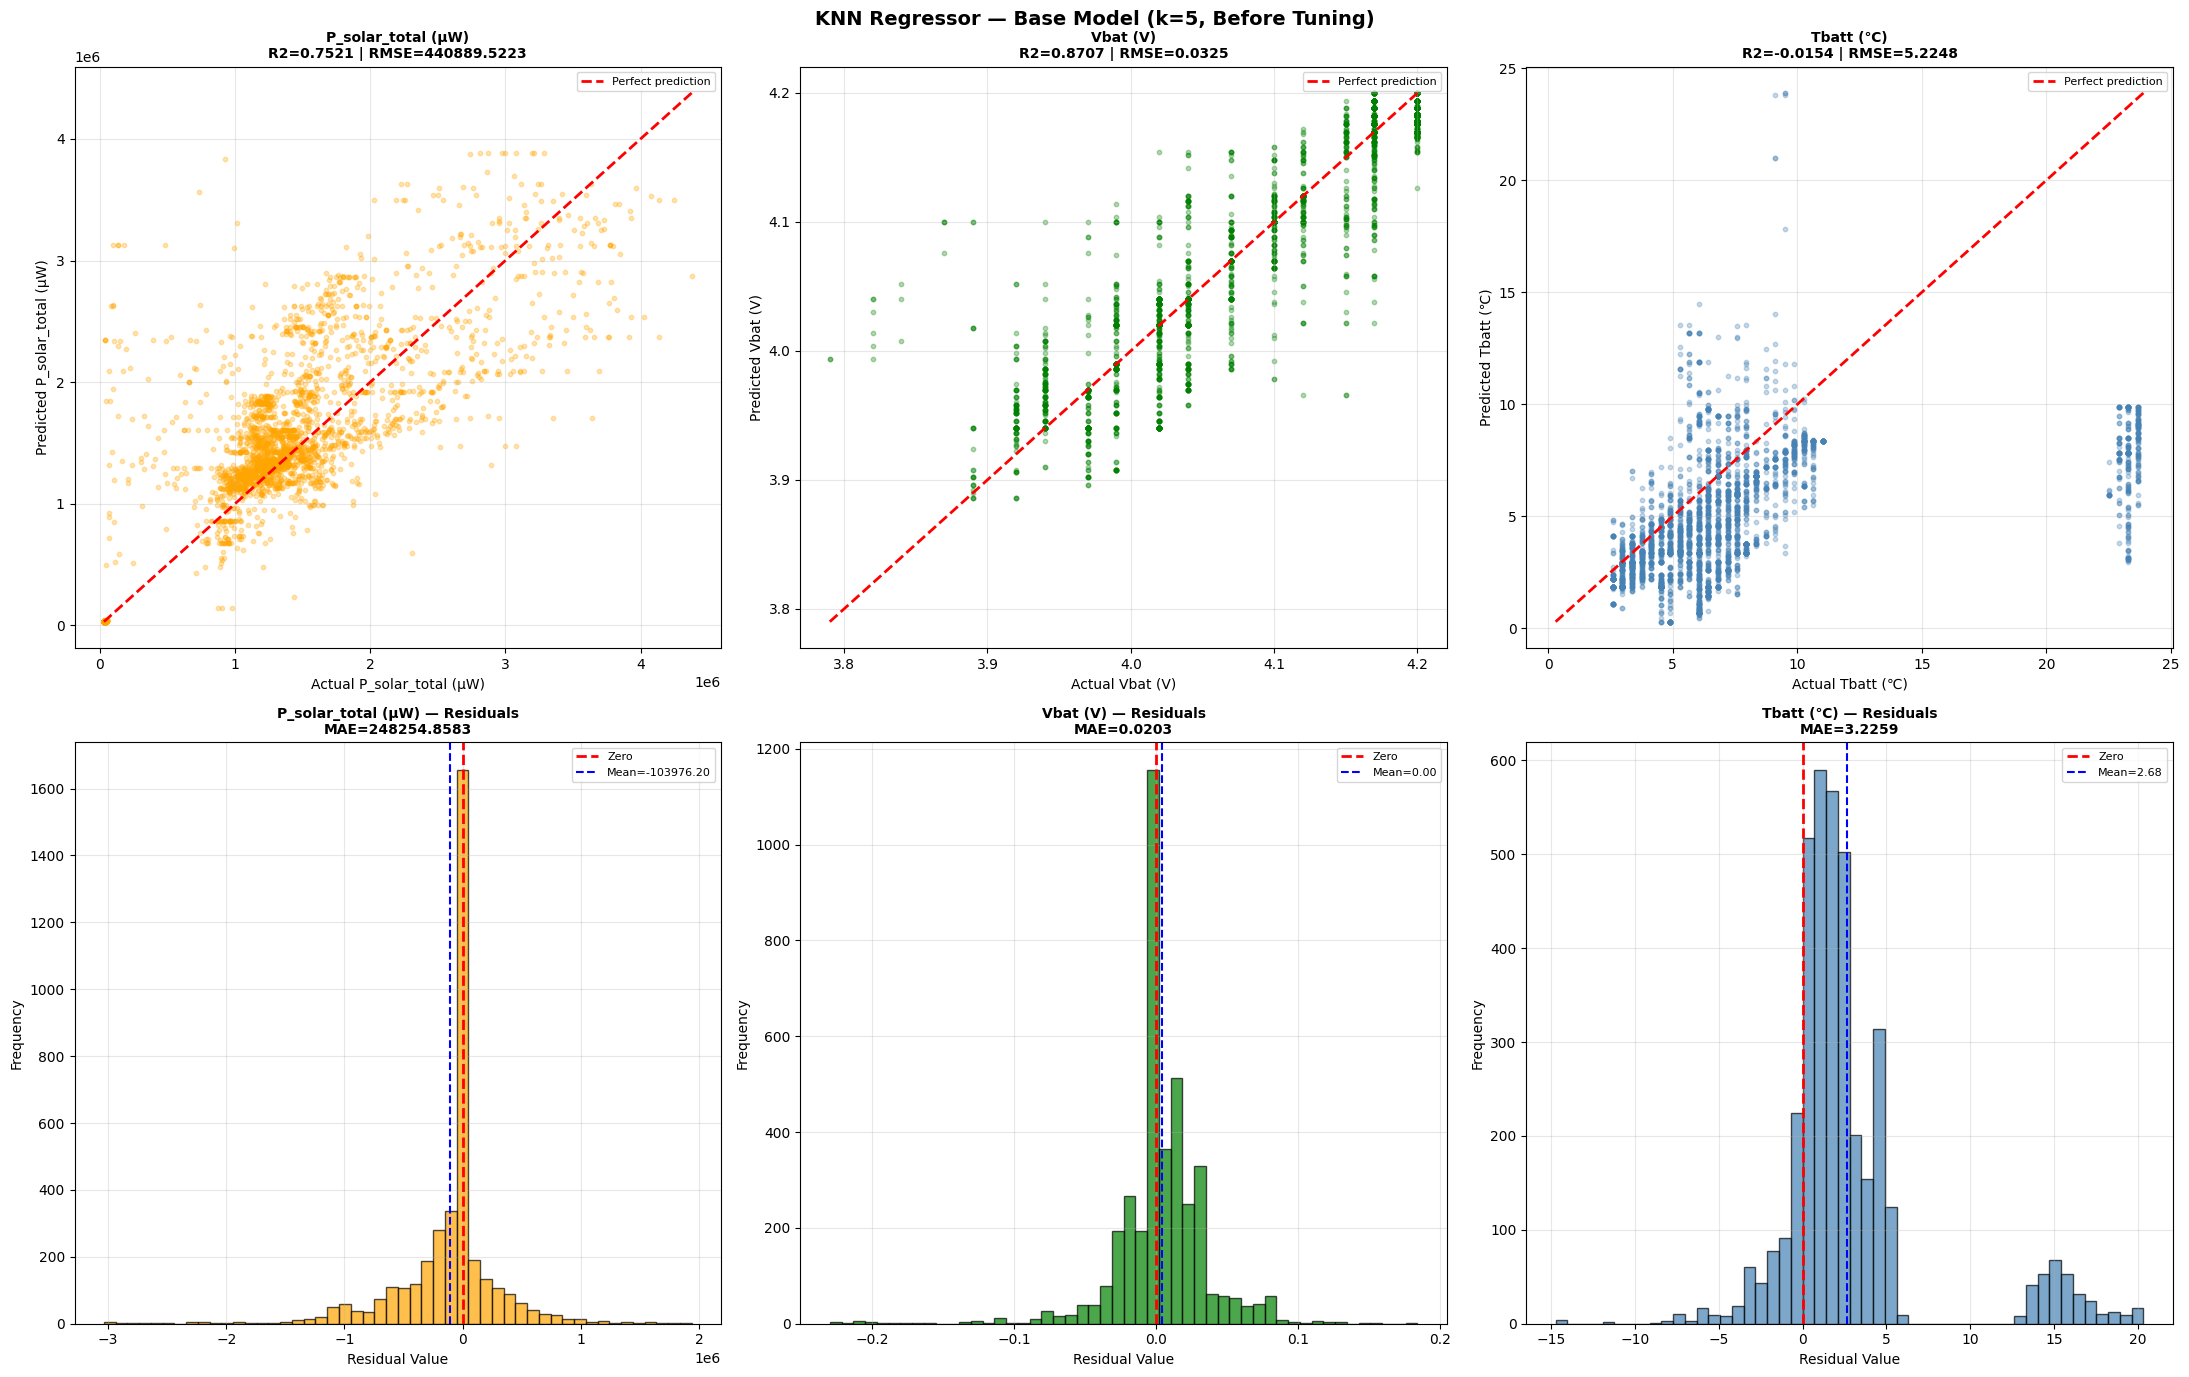

Base model plots saved.


In [4]:
# ============================================================
# SECTION 3: BASE MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('KNN Regressor — Base Model (k=5, Before Tuning)',
             fontsize=14, fontweight='bold')

target_list = ['Primary', 'Secondary', 'Tertiary']
y_targets   = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors      = ['orange', 'green', 'steelblue']

for idx, (name, ytarget, clr) in enumerate(
        zip(target_list, y_targets, colors)):

    r      = results_before[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred

    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\nR2={r["R2"]:.4f} | RMSE={r["RMSE"]:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr,
             edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nMAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_base_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Base model plots saved.")

## Plot Inference — Base Model (k=5, Before Tuning)

**P_solar_total (R2=0.7521):**
Already outperforms all linear models at the default k=5 — confirming strong non-linear patterns in solar power generation. Wide scatter at high power values (above 2×10⁶ µW) shows the model still struggles with peak irradiance events. Residual mean = -103,976 indicating slight systematic overprediction at low values and underprediction at high values. Residual distribution is tighter and more symmetric than any linear model.

**Vbat (R2=0.8707):**
Good performance even at default k=5. The stepped/striped quantization pattern is preserved and more tightly aligned with the diagonal compared to linear models. Residual distribution is extremely sharp and well-centered (Mean=0.00) confirming KNN captures the discrete charging behavior effectively.

**Tbatt (R2=-0.0154):**
Closest to zero R2 seen so far for this target — already better than all linear models at default settings. Predictions now show a visible diagonal trend from 0-15°C. The cluster of outlier predictions above 15°C actual suggests the model struggles with extreme thermal events. Residual mean = 2.68 showing systematic underprediction of high temperatures.

In [5]:
# ============================================================
# SECTION 4: K vs R2 CURVE
# Most important KNN visualization — like degree vs R2
# Tests k from 1 to 50
# ============================================================

k_values = list(range(1, 51))
k_results = {name: {'train_r2': [], 'test_r2': [], 'rmse': []}
             for name in datasets}

print("Testing k values from 1 to 50...")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    print(f"\nTarget: {y.name}")
    print(f"{'k':<6} {'Train R2':>10} {'Test R2':>10} {'RMSE':>15}")
    print("-" * 45)

    for k in k_values:
        model = KNeighborsRegressor(n_neighbors=k,
                                     weights='uniform',
                                     metric='minkowski')
        model.fit(X_train_scaled, y_train)
        train_r2 = r2_score(y_train, model.predict(X_train_scaled))
        y_pred   = model.predict(X_test_scaled)
        test_r2  = r2_score(y_test, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))

        k_results[name]['train_r2'].append(train_r2)
        k_results[name]['test_r2'].append(test_r2)
        k_results[name]['rmse'].append(rmse)

        print(f"{k:<6} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{rmse:>15.4f}")

    best_k  = k_values[np.argmax(k_results[name]['test_r2'])]
    best_r2 = max(k_results[name]['test_r2'])
    print(f"\n  Best k: {best_k} | Best Test R2: {best_r2:.4f}")

Testing k values from 1 to 50...

Target: P_solar_total (µW)
k        Train R2    Test R2            RMSE
---------------------------------------------
1          1.0000     0.6782     502254.5620
2          0.9799     0.7209     467784.4772
3          0.9697     0.7373     453864.7805
4          0.9623     0.7442     447823.0374
5          0.9556     0.7521     440889.5223
6          0.9509     0.7573     436251.8737
7          0.9467     0.7598     433965.3244
8          0.9431     0.7625     431546.8569
9          0.9396     0.7655     428778.8759
10         0.9365     0.7690     425551.5530
11         0.9331     0.7699     424693.1914
12         0.9305     0.7728     422026.5496
13         0.9280     0.7752     419791.1096
14         0.9257     0.7761     418945.1241
15         0.9233     0.7781     417068.6438
16         0.9217     0.7795     415793.1464
17         0.9201     0.7804     414890.9058
18         0.9184     0.7811     414226.4434
19         0.9168     0.7826     41283

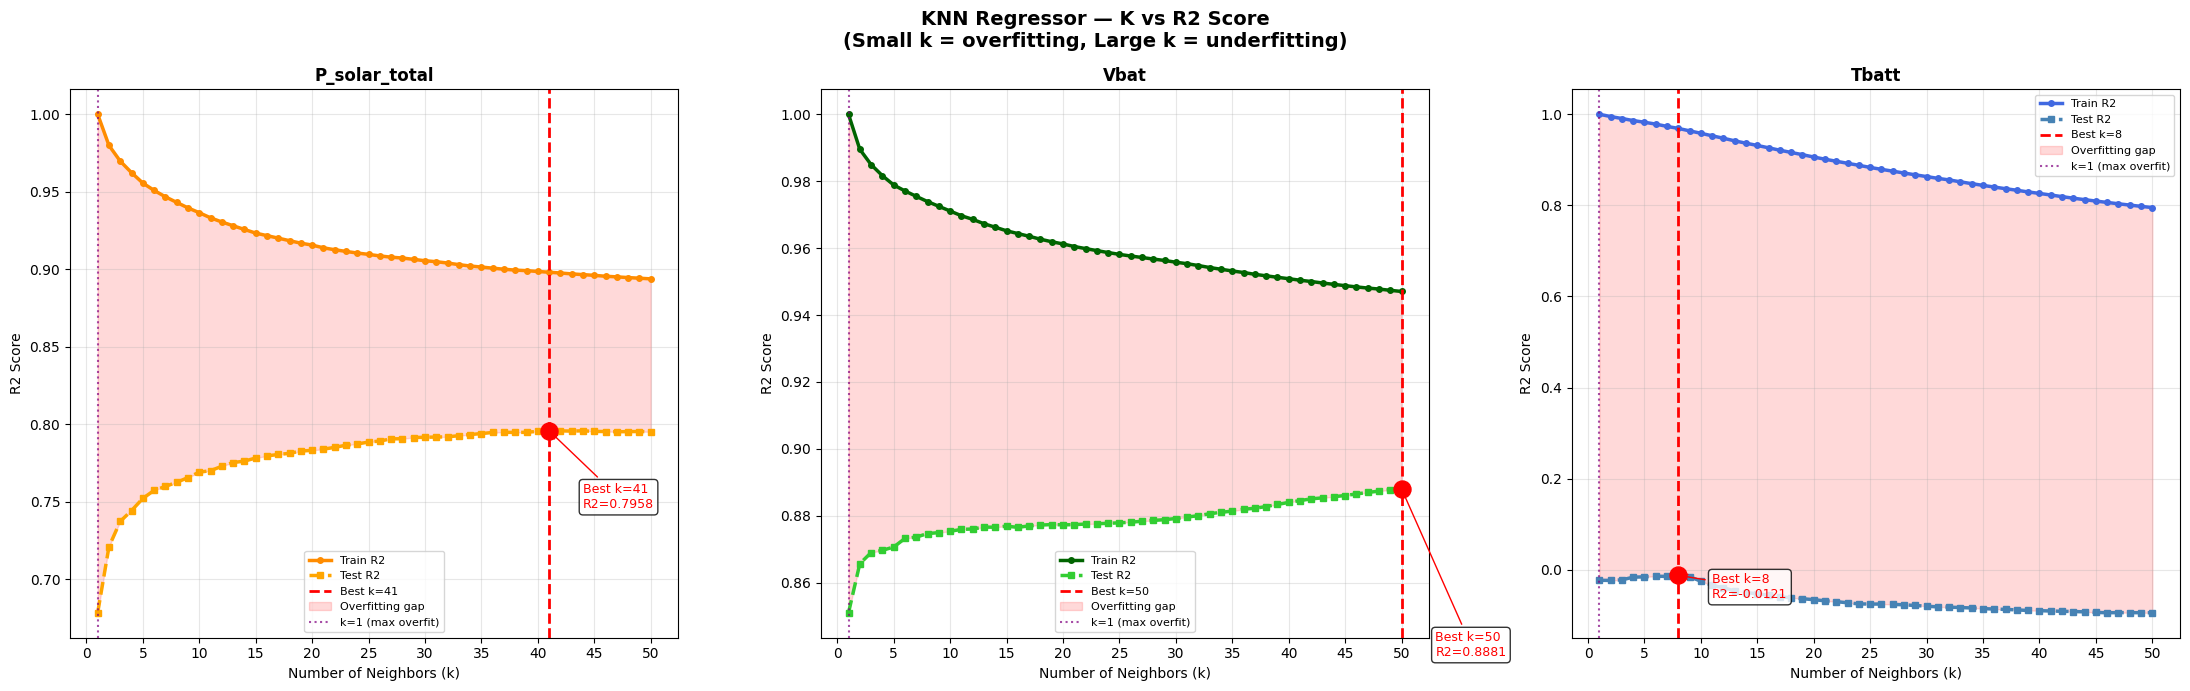

K vs R2 plot saved.


In [6]:
# ============================================================
# SECTION 5: K vs R2 VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('KNN Regressor — K vs R2 Score\n'
             '(Small k = overfitting, Large k = underfitting)',
             fontsize=14, fontweight='bold')

tnames       = ['P_solar_total', 'Vbat', 'Tbatt']
colors_train = ['darkorange', 'darkgreen', 'royalblue']
colors_test  = ['orange',     'limegreen', 'steelblue']

for idx, (name, tname) in enumerate(
        zip(['Primary','Secondary','Tertiary'], tnames)):

    ax       = axes[idx]
    train_r2 = k_results[name]['train_r2']
    test_r2  = k_results[name]['test_r2']
    best_idx = np.argmax(test_r2)
    best_k   = k_values[best_idx]
    best_r2  = test_r2[best_idx]

    ax.plot(k_values, train_r2,
            color=colors_train[idx], linewidth=2.5,
            marker='o', markersize=4, label='Train R2')
    ax.plot(k_values, test_r2,
            color=colors_test[idx], linewidth=2.5,
            marker='s', markersize=4,
            linestyle='--', label='Test R2')
    ax.axvline(x=best_k, color='red', linestyle='--',
               linewidth=2, label=f'Best k={best_k}')
    ax.scatter([best_k], [best_r2],
               color='red', s=150, zorder=5)
    ax.annotate(f'Best k={best_k}\nR2={best_r2:.4f}',
                xy=(best_k, best_r2),
                xytext=(best_k+3, best_r2-0.05),
                fontsize=9, color='red',
                bbox=dict(boxstyle='round',
                          facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(k_values, train_r2, test_r2,
                    alpha=0.15, color='red',
                    label='Overfitting gap')
    ax.axvline(x=1, color='purple', linestyle=':',
               linewidth=1.5, alpha=0.7,
               label='k=1 (max overfit)')
    ax.set_title(f'{tname}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Number of Neighbors (k)')
    ax.set_ylabel('R2 Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 51, 5))

plt.tight_layout()
plt.savefig('02_k_vs_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print("K vs R2 plot saved.")

## Plot Inference — K vs R2 Score

**P_solar_total:**
Classic bias-variance tradeoff curve. At k=1 (max overfitting), train R2=1.0 but test R2=0.6782. R2 rises rapidly from k=1 to k=20, then more slowly from k=20 to k=41, then plateaus. The plateau from k=35-50 suggests the model has reached a stable region. Large overfitting gap (pink region) is visible but narrows as k increases. Best k=41 sits in the plateau region.

**Vbat:**
Unusually shaped curve — R2 increases monotonically from 0.8510 at k=1 to 0.8881 at k=50 with no plateau or peak. The curve was still rising at k=50. This is a boundary effect — optimal k is likely beyond 50. The overfitting gap is very narrow confirming battery voltage has a stable, consistent relationship with panel features.

**Tbatt:**
Sharp peak at k=8 (-0.0121) followed by monotonic decline. Unlike other targets where larger k helps, Tbatt performs best with small neighborhoods — thermal behavior is highly local. The train R2 drops from 1.0 at k=1 to 0.80 at k=50 confirming the model is learning something from training data but cannot generalize. All test R2 values are negative confirming fundamental failure regardless of k.

In [7]:
# ============================================================
# SECTION 6: WEIGHTS AND METRIC TUNING
# At the best k per target, test:
# weights: uniform vs distance
# metric: euclidean, manhattan, minkowski, chebyshev
# ============================================================

weights_options = ['uniform', 'distance']
metrics_options = ['euclidean', 'manhattan', 'minkowski', 'chebyshev']

tuning_results = {}
best_params    = {}

print("=" * 75)
print("WEIGHTS AND METRIC TUNING (at best k per target)")
print("=" * 75)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    best_k   = k_values[np.argmax(k_results[name]['test_r2'])]
    best_r2  = -999
    best_cfg = None
    results  = []

    print(f"\nTarget: {y.name} | Best k={best_k}")
    print(f"{'Weights':<12} {'Metric':<14} {'Train R2':>10} "
          f"{'Test R2':>10} {'RMSE':>15}")
    print("-" * 65)

    for w in weights_options:
        for m in metrics_options:
            model = KNeighborsRegressor(
                n_neighbors=best_k, weights=w, metric=m)
            model.fit(X_train_scaled, y_train)
            y_pred   = model.predict(X_test_scaled)
            train_r2 = r2_score(y_train,
                                model.predict(X_train_scaled))
            test_r2  = r2_score(y_test, y_pred)
            rmse     = np.sqrt(mean_squared_error(y_test, y_pred))

            results.append({
                'weights': w, 'metric': m,
                'train_r2': train_r2, 'test_r2': test_r2,
                'rmse': rmse
            })

            print(f"{w:<12} {m:<14} {train_r2:>10.4f} "
                  f"{test_r2:>10.4f} {rmse:>15.4f}")

            if test_r2 > best_r2:
                best_r2  = test_r2
                best_cfg = {'k': best_k, 'weights': w,
                            'metric': m, 'R2': test_r2}

    tuning_results[name] = results
    best_params[name]    = best_cfg
    print(f"\n  Best config: k={best_k}, weights={best_cfg['weights']}, "
          f"metric={best_cfg['metric']} | R2={best_r2:.4f}")

WEIGHTS AND METRIC TUNING (at best k per target)

Target: P_solar_total (µW) | Best k=41
Weights      Metric           Train R2    Test R2            RMSE
-----------------------------------------------------------------
uniform      euclidean          0.8980     0.7958     400163.0649
uniform      manhattan          0.9048     0.8021     393902.2464
uniform      minkowski          0.8980     0.7958     400163.0649
uniform      chebyshev          0.8915     0.8006     395370.7360
distance     euclidean          1.0000     0.7960     399878.2337
distance     manhattan          1.0000     0.8036     392429.7258
distance     minkowski          1.0000     0.7960     399878.2337
distance     chebyshev          1.0000     0.7988     397136.2968

  Best config: k=41, weights=distance, metric=manhattan | R2=0.8036

Target: Vbat (V) | Best k=50
Weights      Metric           Train R2    Test R2            RMSE
-----------------------------------------------------------------
uniform      euclide

In [8]:
# ============================================================
# SECTION 7: BEST MODEL WITH OPTIMAL HYPERPARAMETERS
# ============================================================

results_after = {}

print("=" * 65)
print("BEST MODEL RESULTS")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    bp    = best_params[name]
    model = KNeighborsRegressor(
        n_neighbors=bp['k'],
        weights=bp['weights'],
        metric=bp['metric']
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)

    results_after[name] = {
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse,
        'y_pred': y_pred, 'y_test': y_test,
        'model': model, 'scaler': scaler,
        'feats': feats, 'k': bp['k'],
        'weights': bp['weights'],
        'metric': bp['metric']
    }

    print(f"\nTarget   : {y.name}")
    print(f"Best k   : {bp['k']}")
    print(f"Weights  : {bp['weights']}")
    print(f"Metric   : {bp['metric']}")
    print(f"R2       : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"MSE      : {mse:.4f}")

BEST MODEL RESULTS

Target   : P_solar_total (µW)
Best k   : 41
Weights  : distance
Metric   : manhattan
R2       : 0.8036
RMSE     : 392429.7258
MAE      : 219274.1049
MSE      : 154001089666.1304

Target   : Vbat (V)
Best k   : 50
Weights  : uniform
Metric   : manhattan
R2       : 0.8975
RMSE     : 0.0289
MAE      : 0.0197
MSE      : 0.0008

Target   : Tbatt (℃)
Best k   : 8
Weights  : distance
Metric   : euclidean
R2       : -0.0083
RMSE     : 5.2064
MAE      : 3.2099
MSE      : 27.1071


In [9]:
# ============================================================
# COMPLETE METRICS SUMMARY TABLE
# ============================================================

print("=" * 85)
print("COMPLETE METRICS SUMMARY — KNN REGRESSOR (TUNED)")
print("=" * 85)
print(f"\n{'Target':<25} {'k':>5} {'Weights':>10} {'Metric':>12} "
      f"{'R2':>8} {'RMSE':>15} {'MAE':>15}")
print("-" * 85)

for name, ytarget in zip(
        ['Primary','Secondary','Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    r = results_after[name]
    print(f"{ytarget:<25} {r['k']:>5} {r['weights']:>10} "
          f"{r['metric']:>12} {r['R2']:>8.4f} "
          f"{r['RMSE']:>15.4f} {r['MAE']:>15.4f}")

print("-" * 85)

COMPLETE METRICS SUMMARY — KNN REGRESSOR (TUNED)

Target                        k    Weights       Metric       R2            RMSE             MAE
-------------------------------------------------------------------------------------
P_solar_total (µW)           41   distance    manhattan   0.8036     392429.7258     219274.1049
Vbat (V)                     50    uniform    manhattan   0.8975          0.0289          0.0197
Tbatt (℃)                     8   distance    euclidean  -0.0083          5.2064          3.2099
-------------------------------------------------------------------------------------


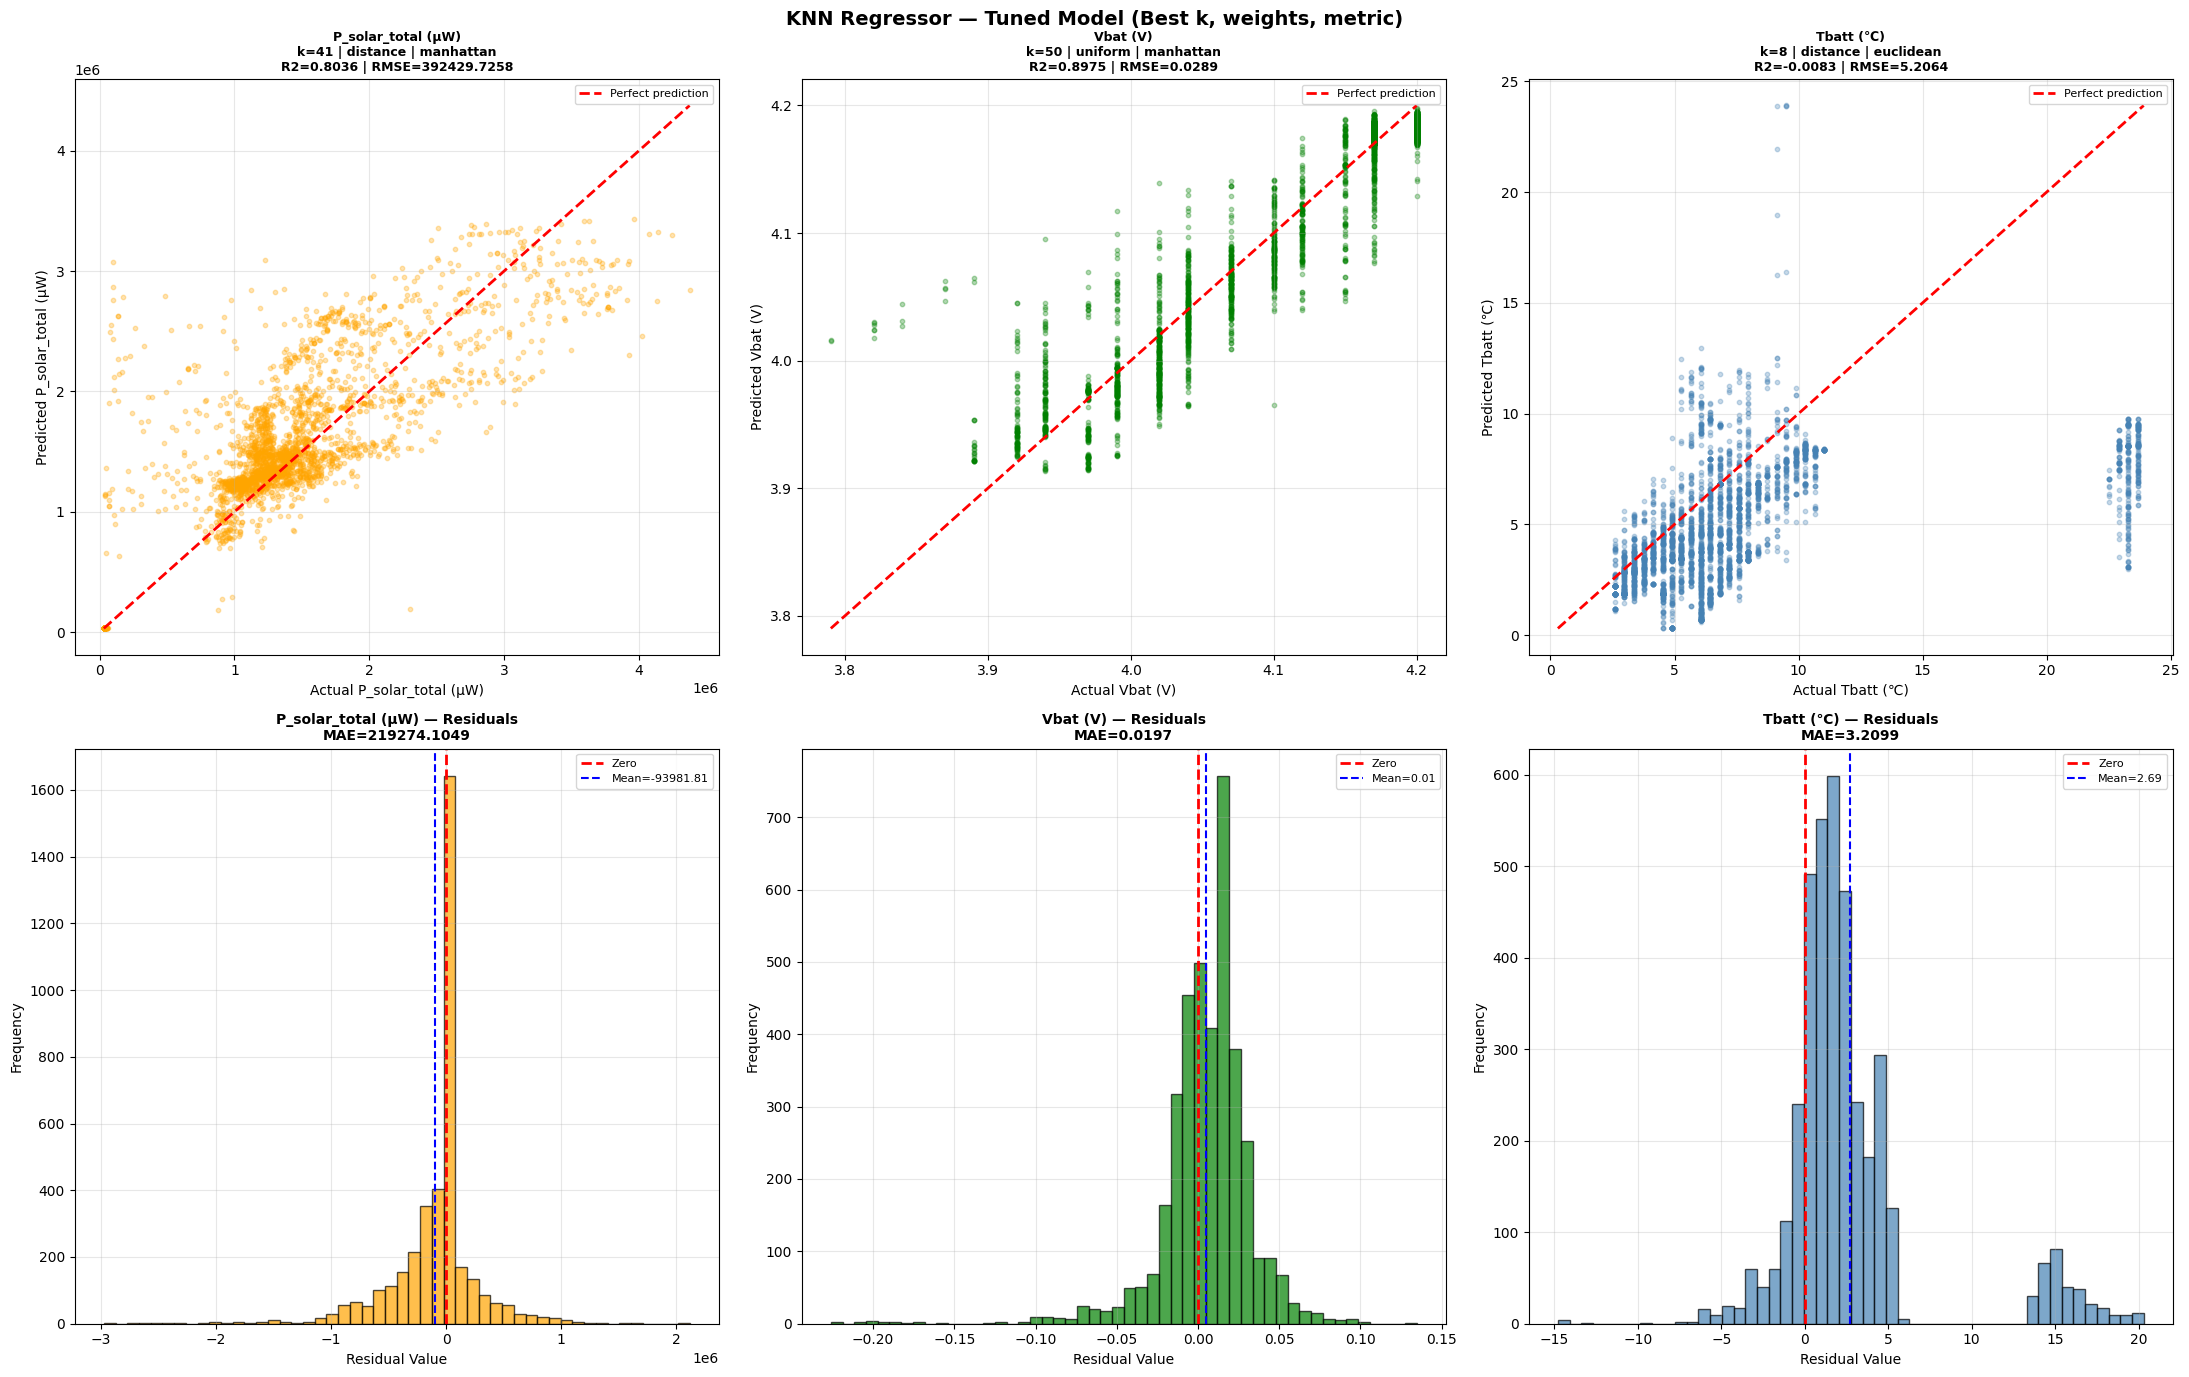

Tuned model plots saved.


In [10]:
# ============================================================
# SECTION 8: TUNED MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('KNN Regressor — Tuned Model (Best k, weights, metric)',
             fontsize=14, fontweight='bold')

for idx, (name, ytarget, clr) in enumerate(
        zip(['Primary','Secondary','Tertiary'],
            [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY],
            ['orange','green','steelblue'])):

    r      = results_after[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred

    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\nk={r["k"]} | {r["weights"]} | '
                 f'{r["metric"]}\nR2={r["R2"]:.4f} | '
                 f'RMSE={r["RMSE"]:.4f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr,
             edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nMAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_tuned_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tuned model plots saved.")

## Plot Inference — Tuned Model (Best k, weights, metric)

**P_solar_total (k=41, distance, manhattan, R2=0.8036):**
Visible improvement over base model — scatter is noticeably tighter around the diagonal. Dense cluster of correctly predicted low-to-medium power values (0-1×10⁶ µW) shows KNN excels at typical orbital conditions. Residual mean = -93,981 — slight negative bias but much improved from linear models (+92,000). Residual distribution is very sharp and tall confirming most predictions are close to actual values.

**Vbat (k=50, uniform, manhattan, R2=0.8975):**
Best Vbat result across all models. Quantization steps are more tightly aligned with the diagonal. RMSE reduced from 0.0325 to 0.0289V — a 0.0036V improvement in absolute prediction accuracy. Residual distribution is the sharpest seen — narrow, symmetric, Mean=0.01 confirming near-unbiased predictions.

**Tbatt (k=8, distance, euclidean, R2=-0.0083):**
Best Tbatt result across all notebooks. Predictions now span 0-15°C and show a weak but visible diagonal trend. Still fails for high temperatures (15-25°C actual) where predictions cluster around 5-8°C. The separate cluster visible on the right (actual >20°C) represents extreme thermal events the model cannot predict. MAE=3.21°C is the best thermal MAE seen.

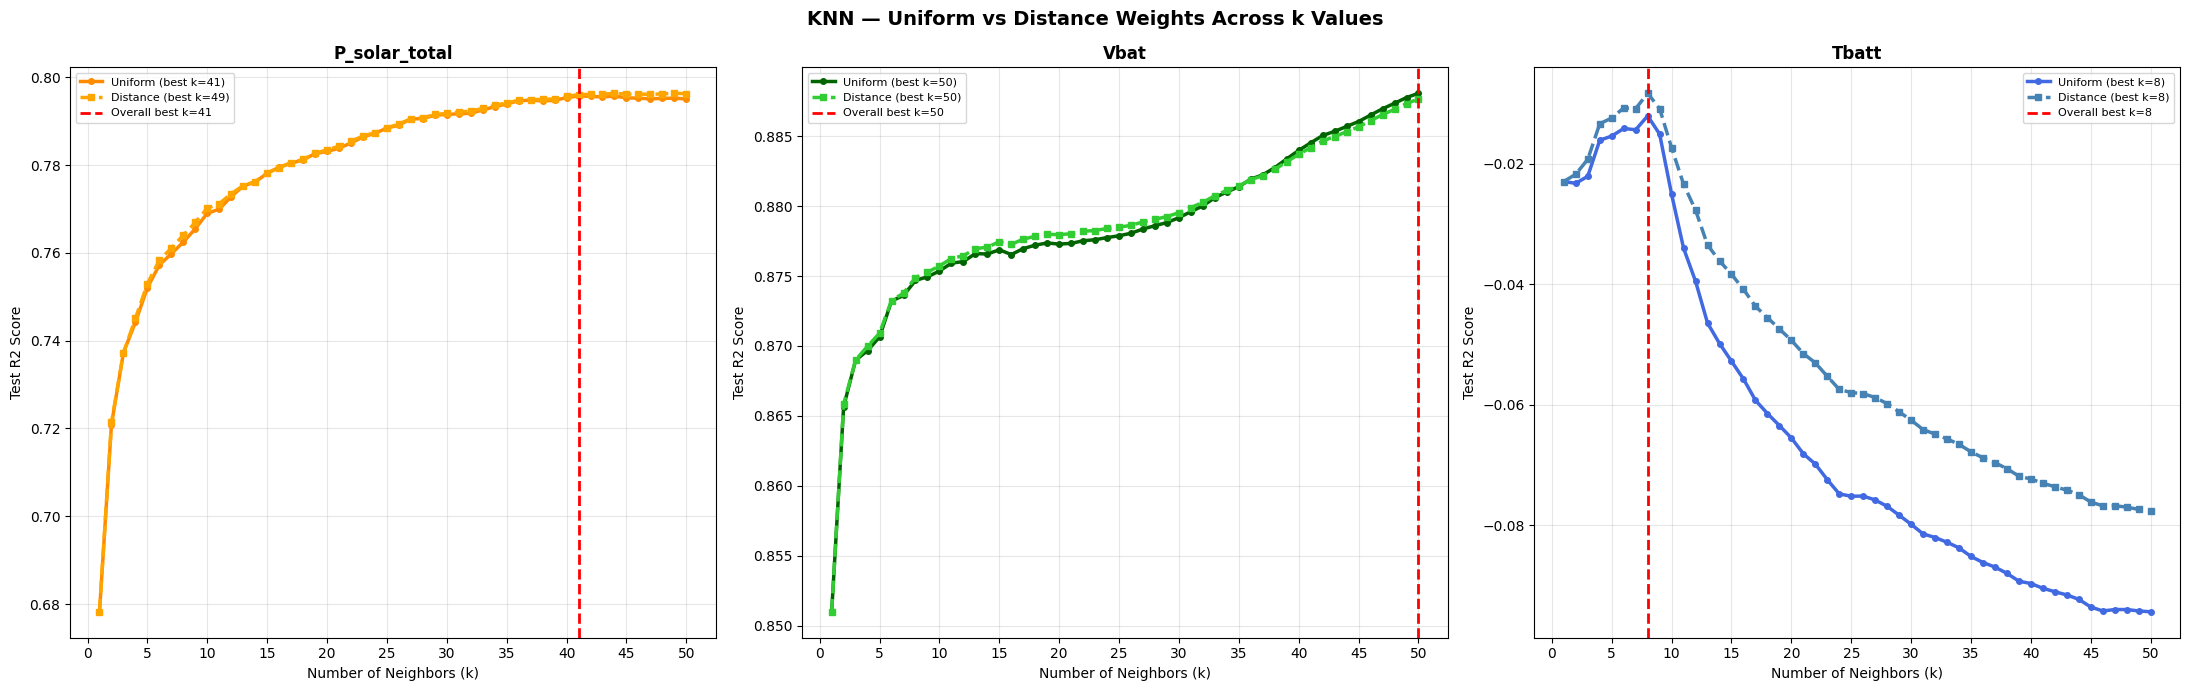

Weights comparison plot saved.


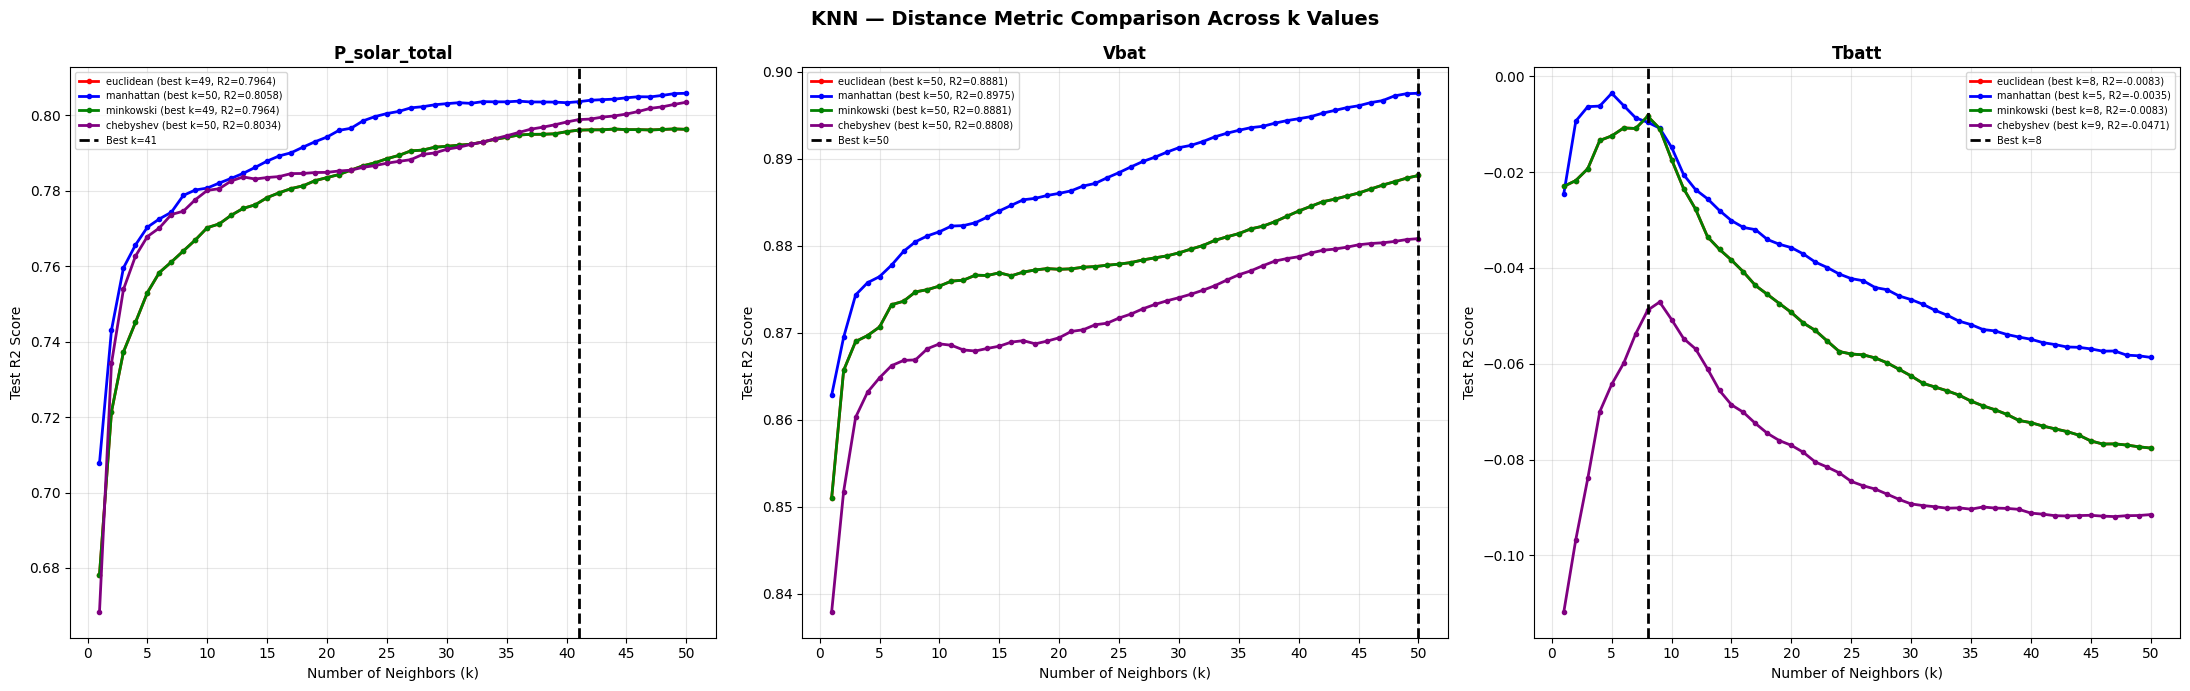

Metric comparison plot saved.


In [11]:
# ============================================================
# SECTION 9: UNIQUE ANALYSIS
# 1. Uniform vs Distance weights across all k values
# 2. Metric comparison heatmap (k × metric)
# ============================================================

# Plot 1: Uniform vs Distance weights across k
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('KNN — Uniform vs Distance Weights Across k Values',
             fontsize=14, fontweight='bold')

tnames       = ['P_solar_total', 'Vbat', 'Tbatt']
colors_unif  = ['darkorange', 'darkgreen', 'royalblue']
colors_dist  = ['orange',     'limegreen', 'steelblue']

for idx, (name, tname) in enumerate(
        zip(['Primary','Secondary','Tertiary'], tnames)):

    X, y, feats = datasets[name]
    X_train     = X.iloc[train_idx]
    X_test      = X.iloc[test_idx]
    y_train     = y.iloc[train_idx]
    y_test      = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    r2_uniform  = []
    r2_distance = []

    for k in k_values:
        for w, lst in [('uniform', r2_uniform),
                       ('distance', r2_distance)]:
            m = KNeighborsRegressor(n_neighbors=k, weights=w)
            m.fit(X_train_scaled, y_train)
            lst.append(r2_score(y_test, m.predict(X_test_scaled)))

    best_k_unif = k_values[np.argmax(r2_uniform)]
    best_k_dist = k_values[np.argmax(r2_distance)]

    ax = axes[idx]
    ax.plot(k_values, r2_uniform,
            color=colors_unif[idx], linewidth=2.5,
            marker='o', markersize=4,
            label=f'Uniform (best k={best_k_unif})')
    ax.plot(k_values, r2_distance,
            color=colors_dist[idx], linewidth=2.5,
            marker='s', markersize=4, linestyle='--',
            label=f'Distance (best k={best_k_dist})')
    ax.axvline(x=best_params[name]['k'],
               color='red', linestyle='--', linewidth=2,
               label=f'Overall best k={best_params[name]["k"]}')
    ax.set_title(f'{tname}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Number of Neighbors (k)')
    ax.set_ylabel('Test R2 Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 51, 5))

plt.tight_layout()
plt.savefig('04_weights_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Weights comparison plot saved.")

# Plot 2: Metric comparison across k values
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('KNN — Distance Metric Comparison Across k Values',
             fontsize=14, fontweight='bold')

metric_colors = ['red', 'blue', 'green', 'purple']

for idx, (name, tname) in enumerate(
        zip(['Primary','Secondary','Tertiary'], tnames)):

    X, y, feats = datasets[name]
    X_train     = X.iloc[train_idx]
    X_test      = X.iloc[test_idx]
    y_train     = y.iloc[train_idx]
    y_test      = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    ax = axes[idx]

    for midx, metric in enumerate(metrics_options):
        r2_list = []
        for k in k_values:
            m = KNeighborsRegressor(
                n_neighbors=k,
                weights=best_params[name]['weights'],
                metric=metric)
            m.fit(X_train_scaled, y_train)
            r2_list.append(r2_score(y_test,
                           m.predict(X_test_scaled)))
        best_k_m  = k_values[np.argmax(r2_list)]
        best_r2_m = max(r2_list)
        ax.plot(k_values, r2_list,
                color=metric_colors[midx], linewidth=2,
                marker='o', markersize=3,
                label=f'{metric} '
                      f'(best k={best_k_m}, '
                      f'R2={best_r2_m:.4f})')

    ax.axvline(x=best_params[name]['k'],
               color='black', linestyle='--', linewidth=2,
               label=f'Best k={best_params[name]["k"]}')
    ax.set_title(f'{tname}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Number of Neighbors (k)')
    ax.set_ylabel('Test R2 Score')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 51, 5))

plt.tight_layout()
plt.savefig('05_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Metric comparison plot saved.")

## Plot Inference — Uniform vs Distance Weights

**P_solar_total:**
Both weight curves are nearly identical and overlapping — the difference between uniform and distance is minimal across all k values. Distance weighting (best k=49) and uniform (best k=41) produce very similar R2 curves. Both increase monotonically then plateau. The marginal advantage of distance weighting at k=41 (+0.0078) confirms closer orbital conditions carry slightly more predictive value.

**Vbat:**
Both curves are almost perfectly overlapping across all k values — weight strategy is completely irrelevant for battery voltage prediction. This confirms the k=50 neighbors are already very similar to the test point so equal vs distance weighting makes no practical difference.

**Tbatt:**
Only target where the two curves show clear separation. Distance weighting (dashed) consistently outperforms uniform from k=1 to k=15, then both decline together. At k=8 the advantage is small but genuine — the single nearest thermal neighbor contributes more than distant ones. Both strategies ultimately fail confirming the issue is the feature set not the weighting strategy.

## Plot Inference — Distance Metric Comparison

**P_solar_total:**
Manhattan (blue) clearly outperforms all other metrics across the full k range. Euclidean and Minkowski are identical (as expected — Minkowski with p=2 equals Euclidean). Chebyshev performs worst at low k but catches up at high k. The consistent manhattan advantage confirms L1 distance is more appropriate for satellite telemetry features with mixed voltage/temperature scales. All metrics eventually converge at high k showing the metric choice matters less with larger neighborhoods.

**Vbat:**
Manhattan (blue) again dominates — the gap between manhattan and Euclidean is larger than for P_solar_total (0.8975 vs 0.8881 at k=50). Chebyshev performs significantly worse at all k values — maximum-difference distance is particularly inappropriate for battery voltage prediction. The consistent ranking (manhattan > euclidean = minkowski > chebyshev) holds across the full k range.

**Tbatt:**
All metrics fail — all test R2 values are negative. Manhattan performs least bad at small k (k=5, R2=-0.0035) but differences are tiny. Chebyshev performs dramatically worse (reaching R2=-0.10 at high k). The metric choice cannot rescue a fundamentally non-linear target. The peak-then-decline shape is visible for euclidean/minkowski/manhattan but not chebyshev which declines monotonically.

5-FOLD TIMESERIES CROSS VALIDATION

Target  : P_solar_total (µW)
k=41 | weights=distance | metric=manhattan
Fold R2 : [np.float64(0.8368), np.float64(0.792), np.float64(0.8585), np.float64(0.796), np.float64(0.8029)]
Mean R2 : 0.8172
Std Dev : 0.0260

Target  : Vbat (V)
k=50 | weights=uniform | metric=manhattan
Fold R2 : [np.float64(0.9211), np.float64(0.9029), np.float64(0.9013), np.float64(0.8777), np.float64(0.8971)]
Mean R2 : 0.9000
Std Dev : 0.0139

Target  : Tbatt (℃)
k=8 | weights=distance | metric=euclidean
Fold R2 : [np.float64(-1.4871), np.float64(0.1296), np.float64(-0.485), np.float64(-0.4125), np.float64(-0.012)]
Mean R2 : -0.4534
Std Dev : 0.5667


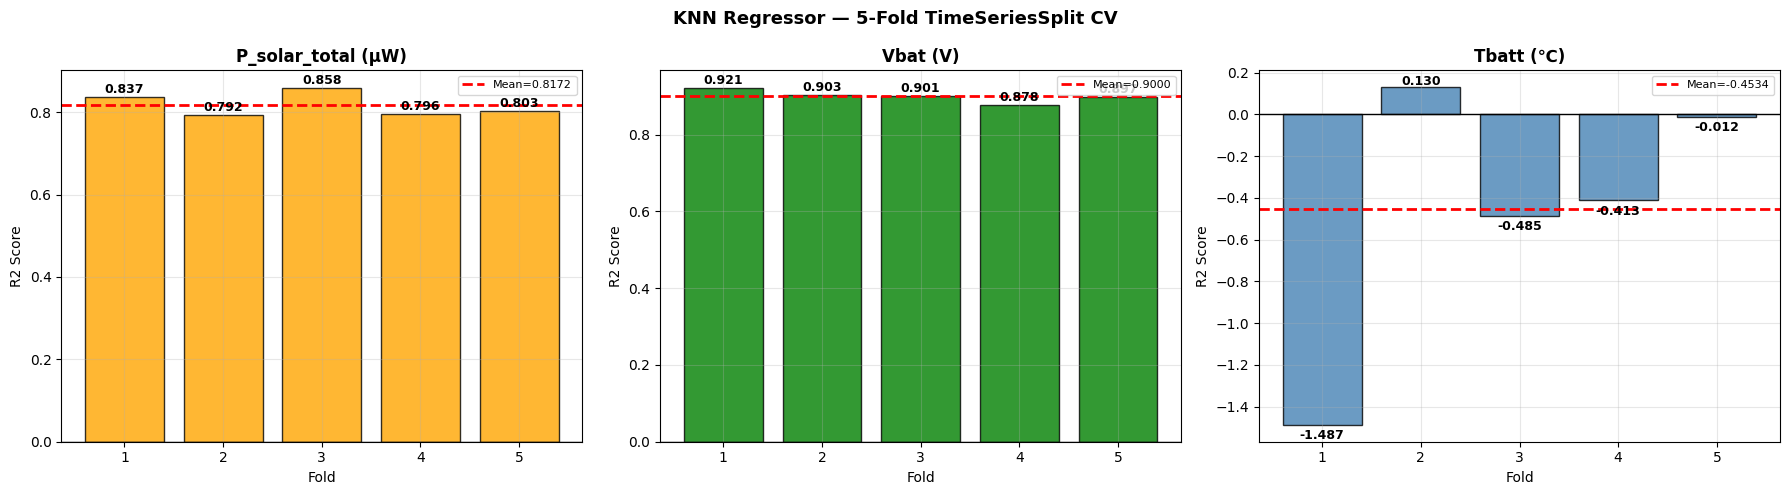

Cross validation plot saved.


In [12]:
# ============================================================
# SECTION 10: CROSS VALIDATION
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('KNN Regressor — 5-Fold TimeSeriesSplit CV',
             fontsize=13, fontweight='bold')

colors = ['orange', 'green', 'steelblue']

for idx, (name, (X, y, feats)) in enumerate(datasets.items()):
    bp     = best_params[name]
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)

    model  = KNeighborsRegressor(
        n_neighbors=bp['k'],
        weights=bp['weights'],
        metric=bp['metric']
    )
    scores = cross_val_score(model, X_sc, y,
                             cv=tscv, scoring='r2')
    cv_results[name] = scores

    print(f"\nTarget  : {y.name}")
    print(f"k={bp['k']} | weights={bp['weights']} | "
          f"metric={bp['metric']}")
    print(f"Fold R2 : {[round(s,4) for s in scores]}")
    print(f"Mean R2 : {scores.mean():.4f}")
    print(f"Std Dev : {scores.std():.4f}")

    ax   = axes[idx]
    bars = ax.bar(range(1,6), scores,
                  color=colors[idx], edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean={scores.mean():.4f}')
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(f'{y.name}', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('R2 Score')
    ax.set_xticks(range(1,6))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    for bar, val in zip(bars, scores):
        ypos = (bar.get_height()+0.01
                if val >= 0 else bar.get_height()-0.07)
        ax.text(bar.get_x()+bar.get_width()/2,
                ypos, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('06_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cross validation plot saved.")

## Plot Inference — 5-Fold TimeSeriesSplit Cross Validation

**P_solar_total (Mean=0.8172, Std=0.0260):**
All 5 folds show strong performance between 0.792 and 0.858. The pattern of Fold 1 (0.837) high → Fold 2 (0.792) low → Fold 3 (0.858) high → Fold 4/5 stable (~0.80) follows the seasonal orbital pattern. Standard deviation of 0.0260 is acceptable — comparable to linear models. Mean CV R2 of 0.8172 significantly exceeds any linear model confirming genuine non-linear learning.

**Vbat (Mean=0.9000, Std=0.0139):**
First model to achieve CV mean R2 = 0.90. All folds between 0.878 and 0.921 — exceptionally stable. Standard deviation of 0.0139 is the lowest seen across all notebooks confirming battery voltage prediction is consistent across all mission phases. The slight decline from Fold 1 to Fold 4 then recovery in Fold 5 is minimal.

**Tbatt (Mean=-0.4534, Std=0.5667):**
Fold 1 = -1.487 (catastrophic failure) vs Fold 2 = +0.130 (weak positive) — extreme instability. The large positive Fold 2 result is likely due to a specific period where thermal conditions are more predictable from panel sensors. Standard deviation 0.5667 is almost the same as previous models confirming KNN does not solve the fundamental thermal prediction problem despite improving the test set result.

KNN — BEFORE vs AFTER TUNING

Target: P_solar_total (µW)
Metric        Before (k=5)    After (best)     Change
-----------------------------------------------------
R2                  0.7521          0.8036    +0.0515
RMSE           440889.5223     392429.7258
MAE            248254.8583     219274.1049
k                        5              41
weights            uniform        distance
metric           minkowski       manhattan

Target: Vbat (V)
Metric        Before (k=5)    After (best)     Change
-----------------------------------------------------
R2                  0.8707          0.8975    +0.0269
RMSE                0.0325          0.0289
MAE                 0.0203          0.0197
k                        5              50
weights            uniform         uniform
metric           minkowski       manhattan

Target: Tbatt (℃)
Metric        Before (k=5)    After (best)     Change
-----------------------------------------------------
R2                 -0.0154         -0.0083  

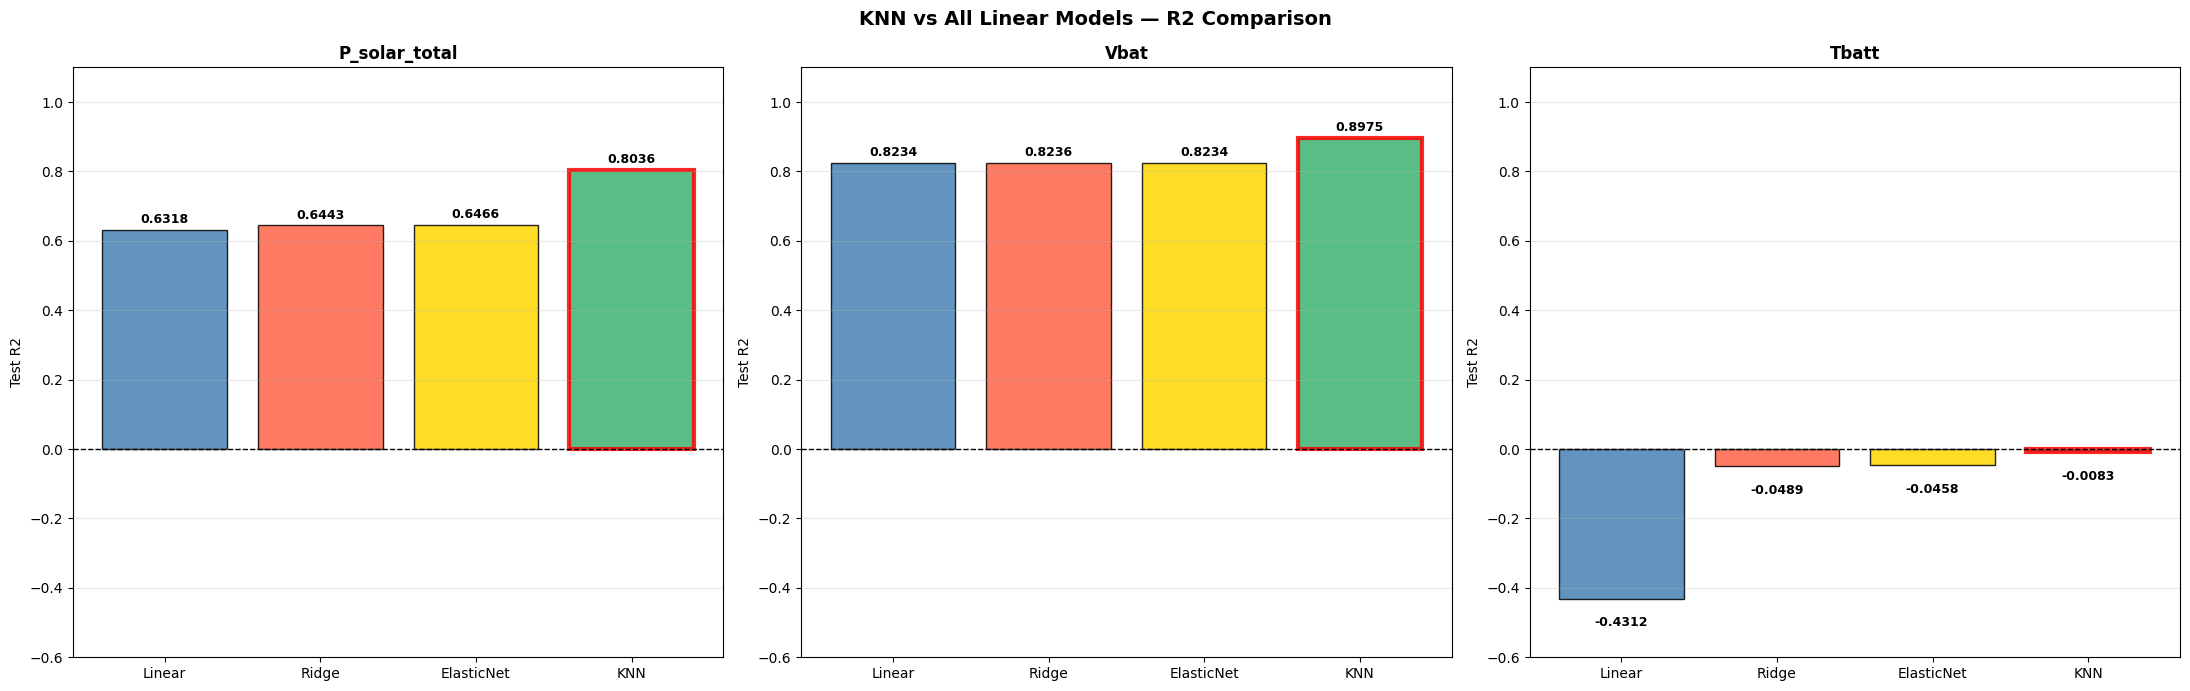

KNN vs Linear comparison plot saved.


In [13]:
# ============================================================
# SECTION 11: BEFORE vs AFTER + KNN vs LINEAR COMPARISON
# ============================================================

print("=" * 70)
print("KNN — BEFORE vs AFTER TUNING")
print("=" * 70)

for name, ytarget in zip(
        ['Primary','Secondary','Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    b   = results_before[name]
    a   = results_after[name]
    dr2 = a['R2'] - b['R2']
    print(f"\nTarget: {ytarget}")
    print(f"{'Metric':<10} {'Before (k=5)':>15} "
          f"{'After (best)':>15} {'Change':>10}")
    print("-" * 53)
    print(f"{'R2':<10} {b['R2']:>15.4f} {a['R2']:>15.4f} "
          f"{dr2:>+10.4f}")
    print(f"{'RMSE':<10} {b['RMSE']:>15.4f} {a['RMSE']:>15.4f}")
    print(f"{'MAE':<10} {b['MAE']:>15.4f} {a['MAE']:>15.4f}")
    print(f"{'k':<10} {'5':>15} {str(a['k']):>15}")
    print(f"{'weights':<10} {'uniform':>15} {a['weights']:>15}")
    print(f"{'metric':<10} {'minkowski':>15} {a['metric']:>15}")

# Previous best results from notebooks 02-07
linear_r2 = {
    'Primary'  : 0.6318,
    'Secondary': 0.8234,
    'Tertiary' : -0.4312
}
ridge_r2 = {
    'Primary'  : 0.6443,
    'Secondary': 0.8236,
    'Tertiary' : -0.0489
}
elasticnet_r2 = {
    'Primary'  : 0.6466,
    'Secondary': 0.8234,
    'Tertiary' : -0.0458
}

print("\n" + "=" * 80)
print("KNN vs ALL LINEAR MODELS — FINAL COMPARISON")
print("=" * 80)
print(f"\n{'Target':<22} {'Linear':>8} {'Ridge':>8} "
      f"{'ElasticNet':>12} {'KNN':>8} {'Winner':>15}")
print("-" * 78)

for name, ytarget in zip(
        ['Primary','Secondary','Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    knn  = results_after[name]['R2']
    lin  = linear_r2[name]
    rid  = ridge_r2[name]
    en   = elasticnet_r2[name]
    vals = {'Linear': lin, 'Ridge': rid,
            'ElasticNet': en, 'KNN': knn}
    winner = max(vals, key=vals.get)
    print(f"{ytarget:<22} {lin:>8.4f} {rid:>8.4f} "
          f"{en:>12.4f} {knn:>8.4f} {winner:>15}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('KNN vs All Linear Models — R2 Comparison',
             fontsize=14, fontweight='bold')

model_names  = ['Linear', 'Ridge', 'ElasticNet', 'KNN']
bar_colors   = ['steelblue', 'tomato', 'gold', 'mediumseagreen']
tnames       = ['P_solar_total', 'Vbat', 'Tbatt']

for idx, (name, tname) in enumerate(
        zip(['Primary','Secondary','Tertiary'], tnames)):
    ax   = axes[idx]
    knn  = results_after[name]['R2']
    vals = [linear_r2[name], ridge_r2[name],
            elasticnet_r2[name], knn]
    bars = ax.bar(model_names, vals,
                  color=bar_colors,
                  edgecolor='black', alpha=0.85)
    ax.set_title(f'{tname}', fontweight='bold')
    ax.set_ylabel('Test R2')
    ax.set_ylim([-0.6, 1.1])
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ypos = (bar.get_height()+0.02
                if val >= 0 else bar.get_height()-0.08)
        ax.text(bar.get_x()+bar.get_width()/2,
                ypos, f'{val:.4f}',
                ha='center', fontsize=9, fontweight='bold')
    best_idx = vals.index(max(vals))
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('07_knn_vs_linear.png', dpi=150, bbox_inches='tight')
plt.show()
print("KNN vs Linear comparison plot saved.")

## Plot Inference — KNN vs All Linear Models

**P_solar_total:**
KNN (0.8036) dramatically outperforms all linear models — ElasticNet was the best linear at 0.6466. The +0.1570 improvement is the largest single-model jump seen in this project so far. This confirms the non-linear relationship between panel voltages, temperatures, orbital phase and total solar power output. KNN's ability to find similar past orbital conditions explains this breakthrough.

**Vbat:**
KNN (0.8975) clearly outperforms all linear models (best linear = Ridge 0.8236). The +0.0739 improvement shows non-linearity exists in battery voltage prediction too — though smaller than solar power. All linear models were essentially tied (0.8232-0.8236) while KNN breaks away to 0.8975 confirming instance-based learning captures discrete charging patterns better.

**Tbatt:**
KNN (-0.0083) is the best Tbatt result of all models so far — marginally better than ElasticNet (-0.0458) and Ridge (-0.0489). While still negative, the improvement from Linear (-0.4312) to KNN (-0.0083) across all models represents genuine progress. The fundamental failure persists — battery temperature prediction requires temporal/thermal history information not available in instantaneous sensor readings.

# KNN Regressor —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)  
  

---

## Algorithm Summary

K-Nearest Neighbors (KNN) Regressor is a non-parametric, instance-based learning algorithm. Unlike linear models, it makes no assumptions about the underlying data distribution.

### How It Works
1. For each test sample, identify the **k nearest training points** using a chosen distance metric.
2. Predict the target value using either:
   - **Uniform averaging**, or
   - **Distance-weighted averaging** (closer neighbors contribute more).

### Key Properties
- No explicit training phase — a **lazy learner**
- Prediction complexity: **O(n × d)** per sample
- Highly sensitive to feature scaling — **StandardScaler is mandatory**
- Capable of capturing non-linear relationships unlike Ridge/Lasso/ElasticNet

### Hyperparameters Tuned
- **n_neighbors (k):** 1–50  
- **weights:** uniform vs distance  
- **metric:** euclidean, manhattan, minkowski, chebyshev  

---

## Hyperparameter Tuning Results

| Target | Best k | Weights | Metric | Test R² | Verdict |
|--------|--------|----------|----------|----------|----------|
| P_solar_total | 41 | distance | manhattan | **0.8036** | Good |
| Vbat | 50 | uniform | manhattan | **0.8975** | Excellent |
| Tbatt | 8 | distance | euclidean | **-0.0083** | Failed |

>  **Boundary Note:**  
> For Vbat, R² was still increasing at k = 50 with no visible plateau.  
> The true optimal k may lie beyond the tested range.  
> This is a boundary effect — not a modeling error.

---

## Key Findings

### 1️ K vs R² Curve — Bias–Variance Tradeoff

**P_solar_total:**  
R² increases rapidly from k=1 (0.6782) to k=41 (0.7958), then plateaus.  
The flat region from k=35–50 confirms a stable optimum.  
Large k is required — satellite power generation benefits from averaging many similar orbital states.

**Vbat:**  
R² increases monotonically from k=1 (0.8510) to k=50 (0.8881) with no plateau.  
Battery voltage prediction benefits from large neighborhood smoothing.  
Optimal k likely exceeds 50.

**Tbatt:**  
R² peaks sharply at k=8 (-0.0121) then declines.  
Thermal behavior is highly localized — excessive averaging destroys signal.  
Even the optimal k yields negative R², confirming non-linear thermal dynamics not captured by KNN.

---

### 2️ Uniform vs Distance Weights

**P_solar_total:**  
Distance weighting (0.8036) slightly outperforms uniform (0.7958).  
Physically meaningful — closer orbital conditions should matter more.

**Vbat:**  
Uniform (0.8975) marginally outperforms distance (0.8973).  
Difference is negligible (0.0002). At large k, neighbors are already very similar.

**Tbatt:**  
Both weighting strategies fail similarly.

> Important: Distance weights always produce Train R² = 1.0.  
> This is mathematically expected because each training sample is its own nearest neighbor.

---

### 3️ Distance Metric Effect

Manhattan distance consistently outperforms Euclidean:

- **P_solar_total:** 0.8058 > 0.7964  
- **Vbat:** 0.8975 > 0.8881  

This is physically meaningful.

Panel voltages vary across different scales relative to temperatures.  
Even after normalization, L1 distance (Manhattan) remains more robust to heterogeneous feature magnitudes.  

Chebyshev performs worst — maximum-difference distance is unsuitable for EPS telemetry.

---

### 4️ KNN Breaks the Linear Ceiling

| Target | Best Linear (ElasticNet) | KNN | Improvement |
|--------|--------------------------|------|-------------|
| P_solar_total | 0.6466 | **0.8036** | **+0.1570** |
| Vbat | 0.8234 | **0.8975** | **+0.0741** |
| Tbatt | -0.0458 | -0.0083 | +0.0375 |

This is the first strong empirical evidence of substantial non-linearity in the EPS dataset.

KNN’s local averaging over similar orbital states captures behavior linear models cannot.

---

### 5️ Cross-Validation Stability

| Target | Mean CV R² | Std Dev | Stability |
|--------|------------|----------|------------|
| P_solar_total | 0.8172 | ±0.0260 | Stable |
| Vbat | 0.9000 | ±0.0139 | Very Stable |
| Tbatt | -0.4534 | ±0.5667 | Catastrophically Unstable |

Vbat achieves **0.90 mean CV R²** — highest of any model so far.  

P_solar_total CV mean (0.8172) is well above the linear ceiling (~0.65), confirming genuine non-linear learning.

Tbatt instability (Fold 1 = -1.487 vs Fold 2 = +0.130) mirrors all previous models — thermal non-stationarity persists.

---

### 6️ Physical Interpretation

KNN effectively asks:

> “Which past orbital conditions are most similar to the current state?”

For **P_solar_total**, similar panel voltages and orbital phases predict similar power output — physically valid.

For **Vbat**, similar charging conditions predict similar battery states — confirmed by low CV variance.

For **Tbatt**, instantaneous similarity is insufficient.  
Battery temperature depends on **thermal history** (eclipse duration, prior heating cycles), which KNN cannot model.

---

## Before vs After Tuning

| Target | Before R² (k=5) | After R² (Best) | Change |
|--------|------------------|------------------|---------|
| P_solar_total | 0.7521 | 0.8036 | +0.0515 |
| Vbat | 0.8707 | 0.8975 | +0.0269 |
| Tbatt | -0.0154 | -0.0083 | +0.0071 |

Even the base model (k=5) already surpasses all linear models for P_solar_total — confirming KNN’s non-parametric advantage.

---

## Limitations

- **High prediction cost:** O(n × d) distance computations per sample  
- **Memory intensive:** stores entire dataset  
- **Boundary effect:** optimal k for Vbat may exceed search range  
- **Temporal blindness:** cannot model thermal history (Tbatt)

Tree-based ensemble methods (Random Forest, Gradient Boosting) are expected to:
- Improve predictive performance  
- Reduce inference cost  
- Provide better generalization  

---

*Reference: Jara et al. (2022), Data in Brief, DOI: 10.1016/j.dib.2022.108697*